In [1]:
import os
os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["JAX_PLATFORM_NAME"] = "cpu"

import glob
import jax_fli as jfli
import datasets

data_files = sorted(glob.glob('/home/wassim/Projects/NBody/jax-fli-result/results/02-density_width_shell_selection/catalogs/variable_width/*.parquet'))
print(f"Found {len(data_files)} parquet files:")
for f in data_files:
    print(" ", os.path.basename(f))

ds = datasets.load_dataset("parquet", data_files=data_files, split="train").with_format("numpy")
print(f"\nDataset: {len(ds)} entries")

Found 5 parquet files:
  nbody_M2048x2048x2048_B6000x6000x6000_Oc0.2589_S80.8159_s0_Ns10_Nst30_nside1024_dw100.0.parquet
  nbody_M2048x2048x2048_B6000x6000x6000_Oc0.2589_S80.8159_s0_Ns10_Nst30_nside1024_dw150.0.parquet
  nbody_M2048x2048x2048_B6000x6000x6000_Oc0.2589_S80.8159_s0_Ns10_Nst30_nside1024_dw200.0.parquet
  nbody_M2048x2048x2048_B6000x6000x6000_Oc0.2589_S80.8159_s0_Ns10_Nst30_nside1024_dw250.0.parquet
  nbody_M2048x2048x2048_B6000x6000x6000_Oc0.2589_S80.8159_s0_Ns10_Nst30_nside1024_dw50.0.parquet


Generating train split: 0 examples [00:00, ? examples/s]


Dataset: 5 entries


In [ ]:
from tqdm import tqdm

spectra_by_width = {}   # dw -> angular_cl (all shells)
cosmo_by_width = {}     # dw -> cosmology
centers_by_width = {}   # dw -> comoving_centers
dw_by_width = {}        # dw -> density_width scalar

p_bar = tqdm(total=len(ds))

for i, item in enumerate(ds):
    catalog = jfli.io.Catalog.from_dataset(item)
    field = catalog.field[0]
    cosmology = catalog.cosmology[0]

    dw = field.density_width[0]
    p_bar.set_description(f"Processing item {i}: dw={dw:.0f} Mpc/h")

    overdensity_lc = (field / field.mean(axis=1, keepdims=True)) - 1.
    angular_cl = overdensity_lc.angular_cl(method="healpy")

    spectra_by_width[dw] = angular_cl
    cosmo_by_width[dw] = cosmology
    centers_by_width[dw] = field.comoving_centers
    dw_by_width[dw] = dw

    p_bar.update(1)

p_bar.close()
print(f"\nProcessed widths: {sorted(spectra_by_width.keys())}")

Processing item 4: dw=50 Mpc/h: 100%|██████████| 5/5 [02:04<00:00, 24.97s/it] 


Processed widths: [np.float64(50.0), np.float64(100.0), np.float64(150.0), np.float64(200.0), np.float64(250.0)]


: 

In [ ]:
import jax.numpy as jnp
import jax_cosmo as jc

SHELL_INDICES = [-3, -2, -1]
SHELL_INDICES = [s + field.shape[0] for s in SHELL_INDICES]
dw_min = 50.0
dw_max = 250.0

theory_cl_min = {}  # shell_idx -> theory Cl for dw=50
theory_cl_max = {}  # shell_idx -> theory Cl for dw=250

ref_nside = 1024
LMAX = 3 * ref_nside
ells = jnp.arange(LMAX)

for dw_key, label, store in [(dw_min, "min", theory_cl_min), (dw_max, "max", theory_cl_max)]:
    cosmo = cosmo_by_width[dw_key]
    comoving_centers = centers_by_width[dw_key]
    density_width = dw_by_width[dw_key]
    n_shells = len(comoving_centers)

    for s in SHELL_INDICES:
        shell_abs = s % n_shells  # resolve negative index
        r_near = comoving_centers[shell_abs] - density_width / 2
        r_far  = comoving_centers[shell_abs] + density_width / 2
        z_near, z_far = jc.utils.a2z(
            jc.background.a_of_chi(cosmo, jnp.array([r_near, r_far]))
        )
        nz = jfli.tophat_z(float(z_near), float(z_far), gals_per_arcmin2=1.0)
        cl = jfli.compute_theory_cl(
            cosmo,
            ell=ells,
            z_source=[nz],
            probe_type="number_counts",
            nonlinear_fn=jc.power.halofit,
            cross=False,
        )
        store[s] = cl
        print(f"  dw={dw_key:.0f}, shell {s} (abs {shell_abs}): done")

print("\nTheory Cl computed for shells:", SHELL_INDICES)

  dw=50, shell -3 (abs 7): done
  dw=50, shell -2 (abs 8): done
  dw=50, shell -1 (abs 9): done
  dw=250, shell -3 (abs 7): done
  dw=250, shell -2 (abs 8): done
  dw=250, shell -1 (abs 9): done

Theory Cl computed for shells: [-3, -2, -1]


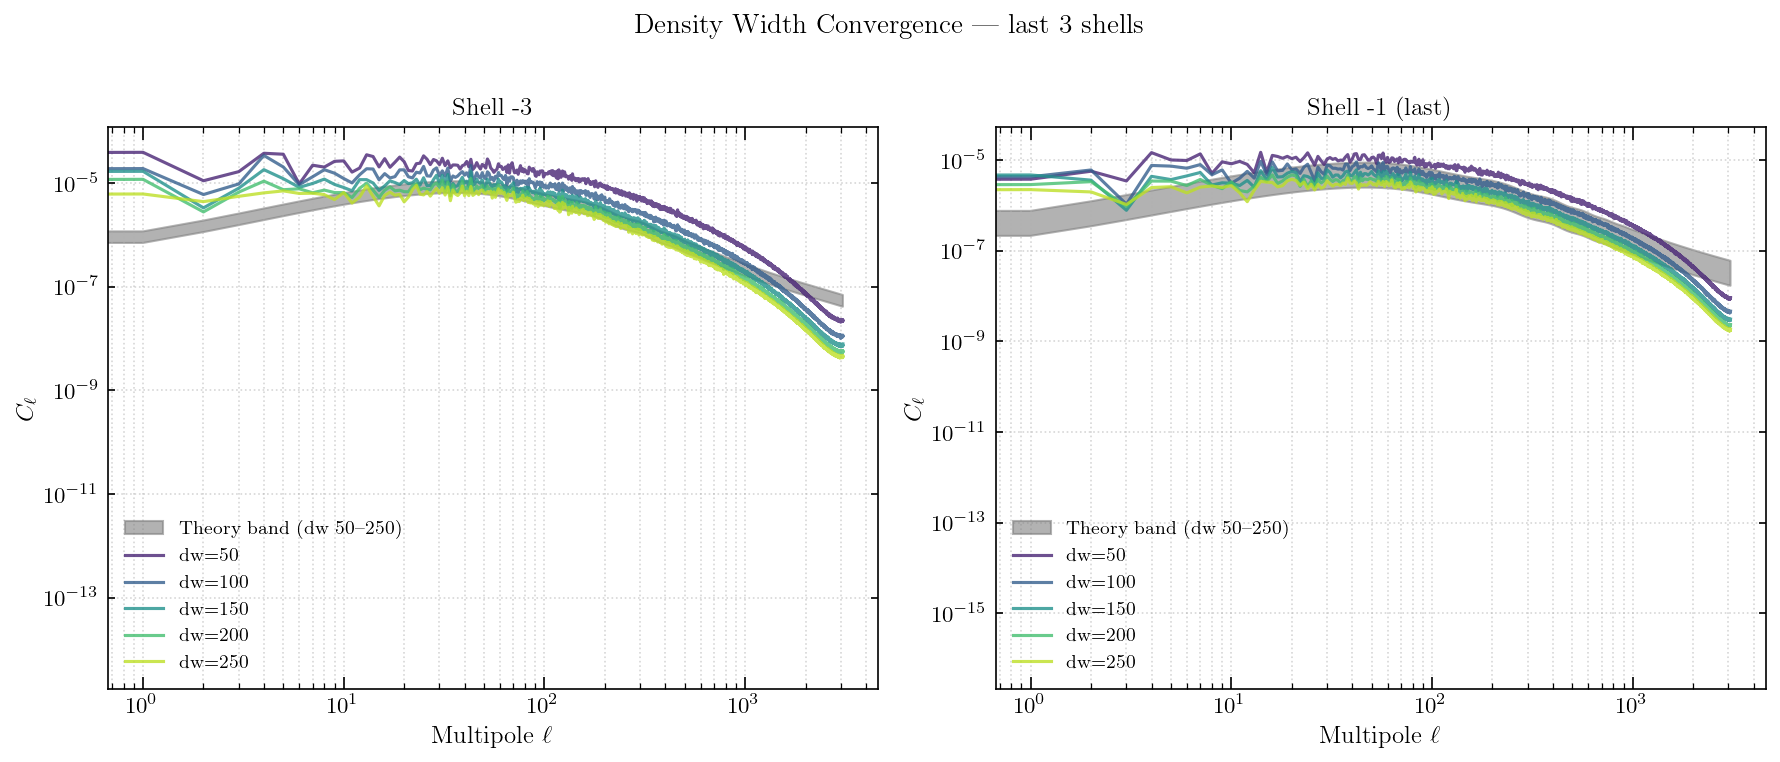

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from utils import set_jcap_style

set_jcap_style()
SHELL_INDICES = [-3, -1]

widths_sorted = sorted(spectra_by_width.keys())
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(widths_sorted)))

shell_labels = {-3: "Shell 9", -1: "Shell 10 (last)"}

fig, axes = plt.subplots(1, len(SHELL_INDICES), figsize=(len(SHELL_INDICES) * 6, 5))

for col, s in enumerate(SHELL_INDICES):
    ax = axes[col]

    # Theory band (fill between dw=50 and dw=250)
    cl_min_arr = jnp.asarray(theory_cl_min[s].spectra)
    cl_max_arr = jnp.asarray(theory_cl_max[s].spectra)
    ell_theory = jnp.asarray(theory_cl_min[s].wavenumber)
    ax.fill_between(ell_theory, cl_min_arr, cl_max_arr,
                    alpha=0.6, color="gray", label=r"Theory band (dw 50--250)")

    # One line per density width
    for c_idx, dw in enumerate(widths_sorted):
        cl_shell = spectra_by_width[dw][s]
        cl_shell.plot(ax=ax, logx=True, logy=True,
                      label=f"dw={dw:.0f}", color=colors[c_idx] , alpha=0.8)

    ax.set_title(shell_labels[s])
    ax.set_xlabel(r"Multipole $\ell$")
    ax.set_ylabel(r"$C_\ell$")
    ax.legend(fontsize="small")

plt.suptitle("Density Width Convergence — last 2 shells", y=1.01)
plt.tight_layout()
plt.show()